In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

marketing = pd.read_csv("../data/raw/marketing_data.csv")

In [2]:
#Analyse des campagnes marketing

In [3]:
#Calculer les KPI

In [4]:
#CTR
marketing["CTR"] = (
    marketing["Clicks"] /
    marketing["Impressions"]
) * 100

In [5]:
#Taux de conversion
marketing["Conversion_Rate"] = (
    marketing["Conversions"] /
    marketing["Clicks"]
) * 100

In [6]:
#CPC
marketing["CPC"] = (
    marketing["Budget"] /
    marketing["Clicks"]
)

In [7]:
#CPA
marketing["CPA"] = (
    marketing["Budget"] /
    marketing["Conversions"]
)

In [8]:
#Afficher :
display(marketing)

,Campaign_ID,Channel,Start_Date,End_Date,Budget,Impressions,Clicks,Conversions,CTR,Conversion_Rate,CPC,CPA
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150,4.000000,7.500000,0.500000,6.666667
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100,1.666667,20.000000,3.000000,15.000000
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200,3.750000,13.333333,1.333333,10.000000
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50,5.000000,5.000000,0.500000,10.000000
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250,5.000000,8.333333,1.000000,12.000000


In [9]:
#Meilleur CTR
marketing.sort_values(
    "CTR",
    ascending=False
)[[
    "Campaign_ID",
    "Channel",
    "CTR"
]]

,Campaign_ID,Channel,CTR
4,5,TV,5.000000
3,4,Email,5.000000
0,1,Online,4.000000
2,3,Social,3.750000
1,2,In-Store,1.666667


In [10]:
# Canal avec le meilleur taux de conversion
best_channel = marketing.loc[
    marketing["Conversion_Rate"].idxmax(),
    "Channel"
]

print("Meilleur canal :", best_channel)

Meilleur canal : In-Store


In [11]:
#Meilleure conversion
marketing.sort_values(
    "Conversion_Rate",
    ascending=False
)[[
    "Campaign_ID",
    "Channel",
    "Conversion_Rate"
]]

,Campaign_ID,Channel,Conversion_Rate
1,2,In-Store,20.000000
2,3,Social,13.333333
4,5,TV,8.333333
0,1,Online,7.500000
3,4,Email,5.000000


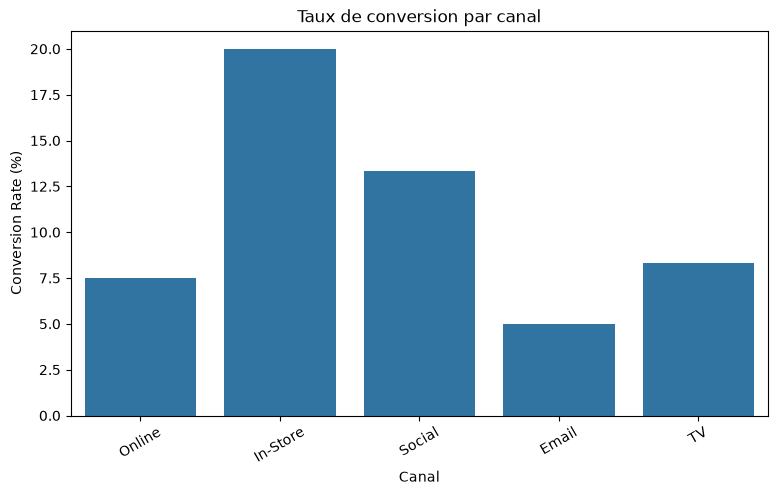

In [12]:
#Graphique
plt.figure(figsize=(9,5))

sns.barplot(
    data=marketing,
    x="Channel",
    y="Conversion_Rate"
)

plt.title("Taux de conversion par canal")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Canal")
plt.xticks(rotation=30)
plt.show()

In [13]:
#Sauvegarder
marketing.to_csv(
    "../data/processed/marketing_kpis.csv",
    index=False
)